In [85]:
!pip install plotly

In [8]:
# import python libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import matplotlib as mpl
from matplotlib.widgets import Button 
import squarify as sq
import seaborn as sns
import plotly.express as px

In [9]:
# Load Dataset from csv
df=pd.read_csv("HR Analyrics.csv")

In [10]:
#Compatibility Fix for colums
if not hasattr(cm,'get_cmap'):
    cm.get_cmap=lambda name='viridis',*args,**keargs: mpl.colormaps[name]

In [12]:
df.shape

(1470, 44)

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
#check for null values
pd.isnull(df).sum()

In [10]:
# drop null values
df.dropna(inplace=True)

In [6]:
df.columns

Index(['Attrition', 'Business Travel', 'CF_ageband', 'CF_attritionlabel',
       'Department', 'EducationField', 'emp no', 'EmployeeNumber', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime', 'Over18',
       'TrainingTimesLastYear', '-2', '0', 'Age', 'CF_attritioncount',
       'CF_attritioncounts', 'CF_attritionrate', 'CF_currentEmployee',
       'DailyRate', 'DistanceFromHome', 'Education', 'Employee_Count',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrent Role',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')

In [22]:
#rename column
df.rename(columns= {'Marital  Status':'MaritalStatus'},inplace=True)

In [23]:
df.columns

Index(['Attrition', 'Business Travel', 'CF_ageband', 'CF_attritionlabel',
       'Department', 'EducationField', 'emp no', 'EmployeeNumber', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime', 'Over18',
       'TrainingTimesLastYear', '-2', '0', 'Age', 'CF_attritioncount',
       'CF_attritioncounts', 'CF_attritionrate', 'CF_currentEmployee',
       'DailyRate', 'DistanceFromHome', 'Education', 'Employee_Count',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrent Role',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')

### Clean data

In [7]:
# clean extra wihte space in data columns
text_cols=['EducationField','Department','Gender','CF_ageband','JobRole','MaritalStatus']
# df['EducationField']=df['EducationField'].fillna('Unknown').astype(str).str.strip()
for col in ['Department','Gender','CF_ageband','JobRole','MaritalStatus']:
    if col in df.columns:
        df[col]=df[col].fillna('Unknown').astype(str).str.strip()

## Exploratory Data Analysis 

In [ ]:
# 1 plotting a bar chart for attriction by department
data=df['Department'].value_counts()
plt.pie(
    data,
    labels=data.index,
    autopct='%.1f%%',
    startangle=90
)

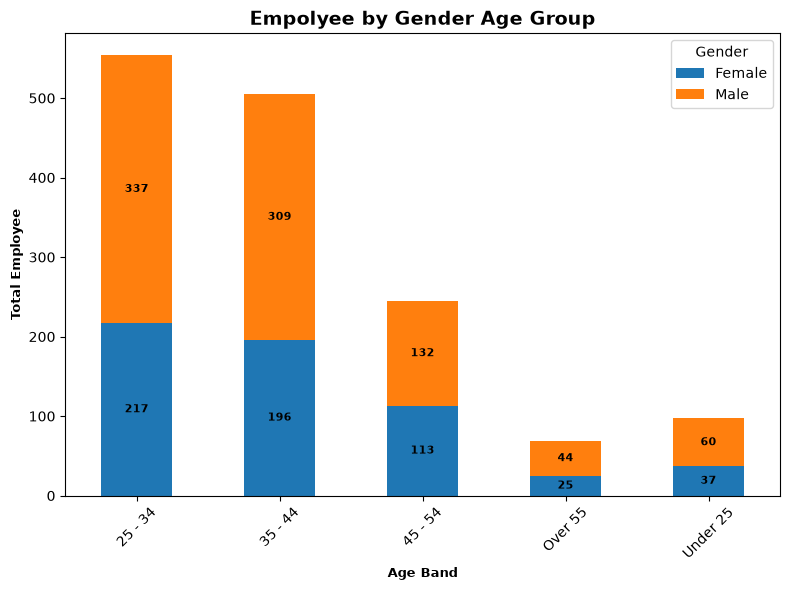

In [13]:
# 2 plotting a bar chart for employee by gender age group
age_genfer_df=df.groupby(['CF_ageband','Gender'])['Employee_Count'].sum().unstack(fill_value=0).sort_values(by='CF_ageband',ascending=True)

fig,ax=plt.subplots(figsize=(8,6))
age_genfer_df.plot(kind='bar',stacked=True,ax=ax)

for container in ax.containers:
    ax.bar_label(container,label_type='center',fontsize=8,color='black',fontweight='bold')
plt.title('Empolyee by Gender Age Group',fontsize=14,fontweight='bold')
plt.xlabel('Age Band',fontsize=9,fontweight='bold')
plt.ylabel('Total Employee',fontsize=9,fontweight='bold')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


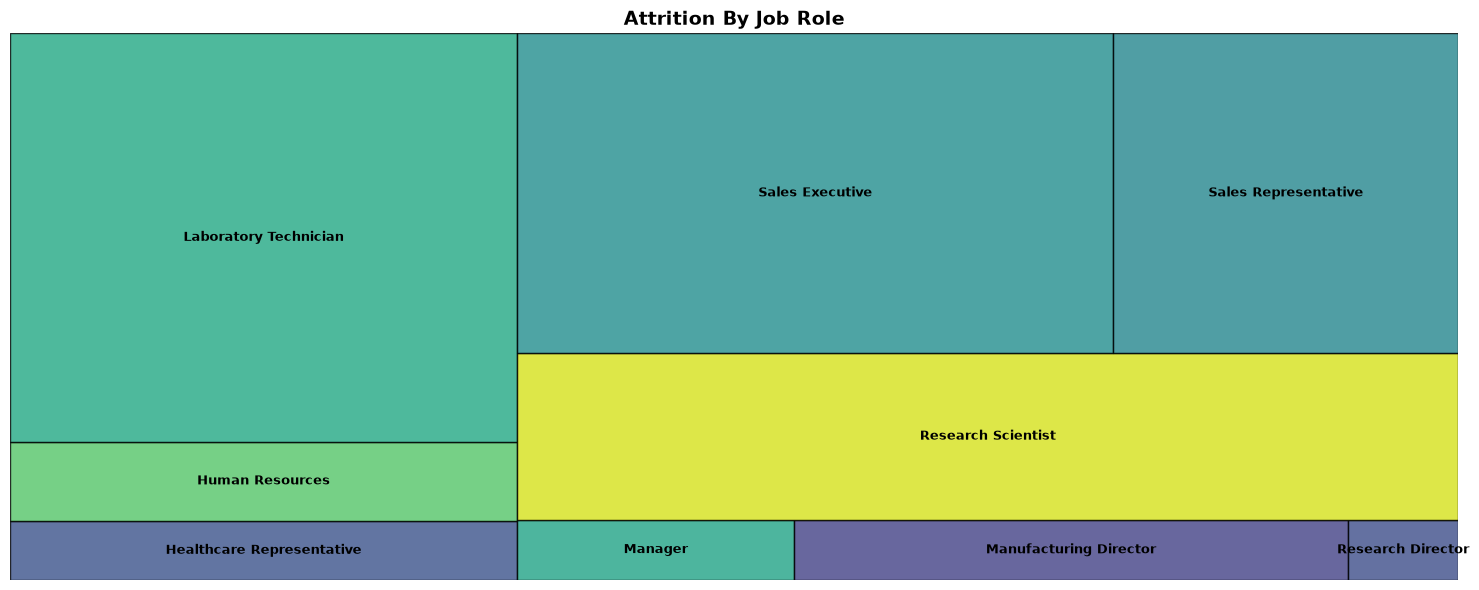

In [14]:
# 3 attraction by job role

attrition_data=df.groupby('JobRole')['CF_attritioncount'].sum().reset_index()
fig,ax=plt.subplots(figsize=(15,6))
sq.plot(sizes=attrition_data['CF_attritioncount'],label=attrition_data['JobRole'],alpha=0.8,ax=ax,
edgecolor='black',linewidth=1,text_kwargs={'fontsize':9,'fontweight':'bold'})
plt.title('Attrition By Job Role',fontsize=14,fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

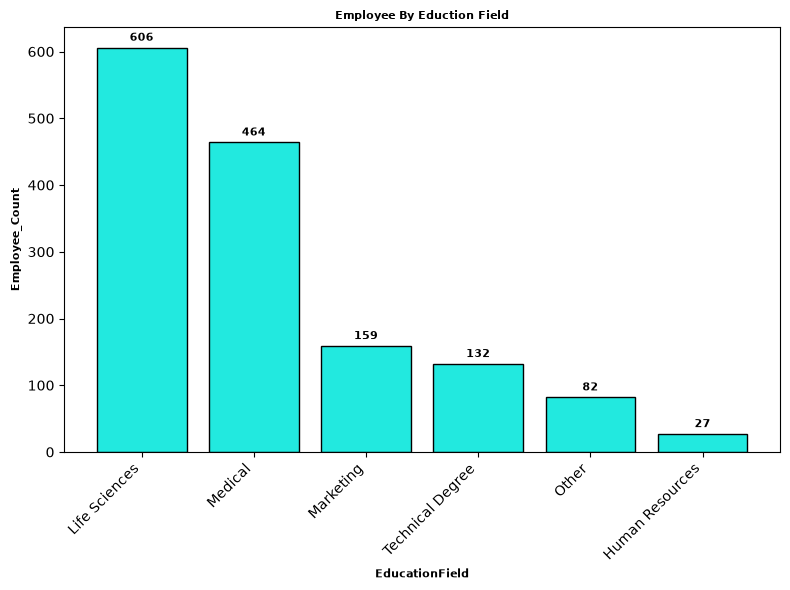

In [16]:
# 4 employee by eduction field

edu_data=df.groupby('EducationField')['Employee_Count'].sum().reset_index().sort_values(by='Employee_Count',ascending=False) # reset index -itgives the table a default numerical index
fig,ax=plt.subplots(figsize=(8,6))
bars=ax.bar(edu_data['EducationField'],edu_data['Employee_Count'],color="#22e9df",edgecolor='black')
ax.bar_label(bars,padding=3,fontsize=8,fontweight='bold')
plt.title('Employee By Eduction Field',fontsize=8,fontweight='bold')
plt.xlabel('EducationField',fontsize=8,fontweight='bold')
plt.ylabel('Employee_Count',fontsize=8,fontweight='bold')  # use for x-axis angle deg.
plt.xticks(rotation=45,ha='right')  # use for padding and spacing
plt.tight_layout()
plt.show()

Text(0, 0.5, '')

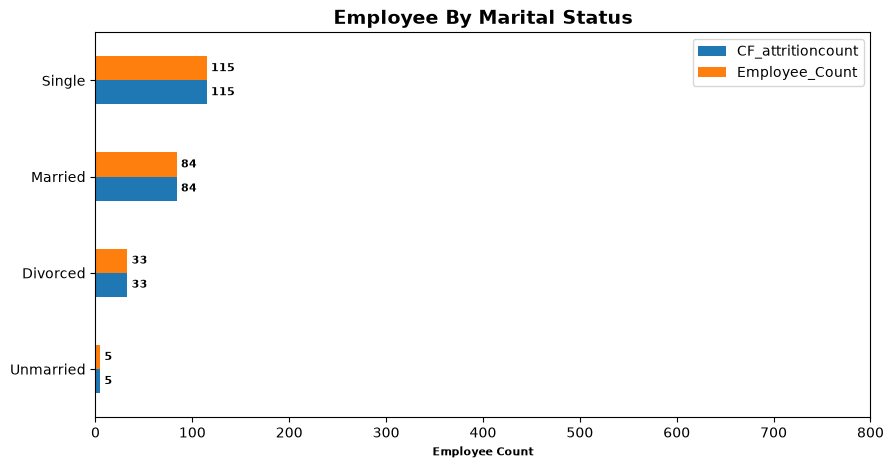

In [129]:
    # 5 employee by Marital status
marital_status=df.groupby('MaritalStatus')[['CF_attritioncount','Employee_Count']].sum().reset_index().sort_values(by='Employee_Count',ascending=True) # reset index -itgives the table a default numerical index
ax=marital_status.plot(
    x='MaritalStatus',
    y=['CF_attritioncount','Employee_Count'],
    kind='barh',
    figsize=(10,5)
)
for container in ax.containers:
    ax.bar_label(container,padding=3,fontsize=8,color='black',fontweight='bold')
    ax.set_xlim(0,800)
    ax.set_xlabel('Employee Count',fontsize=8,fontweight='bold')
    ax.set_ylabel('')
ax.set_title('Employee By Marital Status',fontsize=14,fontweight='bold')
ax.set_xlabel('Employee Count', fontsize=8, fontweight='bold')
ax.set_ylabel('')

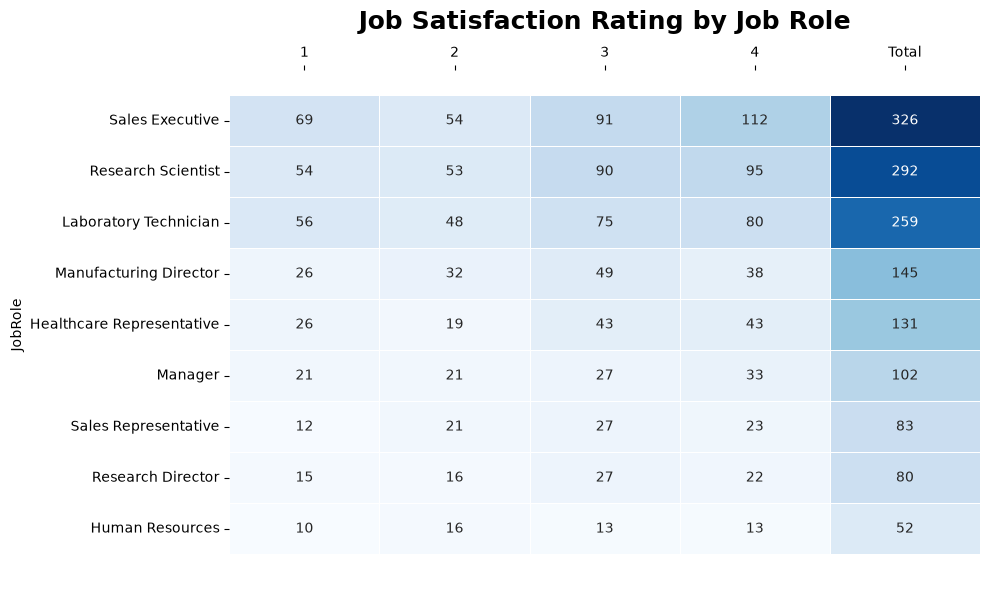

In [18]:
# 1. Create pivot table matrix
# 1. Create pivot table matrix
matrix_data = df.pivot_table(
    index='JobRole',
    columns='JobSatisfaction',
    values='Employee_Count',
    aggfunc='sum',
    fill_value=0
)

# 2. Add 'Total' column and sort rows by total descending
matrix_data['Total'] = matrix_data.sum(axis=1)
matrix_data = matrix_data.sort_values(by='Total', ascending=False)

# 3. Plot heatmap with Seaborn
plt.figure(figsize=(10, 6))
ax=sns.heatmap(
    matrix_data,
    annot=True,          # Displays the numbers inside each cell
    fmt='d',             # Formats numbers as integers (no decimals)
    cmap='Blues',        # Palette gradient: Blues, YlGnBu, viridis, etc.
    linewidths=0.5,      # Grid line separation between cells
    cbar=False            # Color bar legend on the right
)
bottom,top=ax.get_ylim()
ax.set_ylim(bottom+0.5,top-0.5)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
# 4. Styling
plt.title('Job Satisfaction Rating by Job Role', fontsize=18, fontweight='bold', pad=12)
# plt.xlabel('Job Satisfaction Rating', fontsize=11, fontweight='bold')
# plt.ylabel('Job Role', fontsize=11, fontweight='bold')
# plt.xticks(rotation=0)
# plt.yticks(rotation=0)
plt.xlabel('')
plt.tight_layout()
plt.show()